In [2]:
from firedrake import *
import numpy as np
import matplotlib.pyplot as plt
from petsc4py import PETSc

In [3]:
ref = [8, 16, 32, 64]
erros_u, erros_v = [], []

Deriva máxima de energia |E_n - E_0|/E_0: 3.597068393499949e-15
Erro L2 em T=1.0: u = 8.411e-04, v = 5.516e-02
Deriva máxima de energia |E_n - E_0|/E_0: 2.861575057954144e-14
Erro L2 em T=1.0: u = 1.074e-04, v = 1.271e-02
Deriva máxima de energia |E_n - E_0|/E_0: 1.2526744344250757e-13
Erro L2 em T=1.0: u = 9.363e-05, v = 1.152e-03
Deriva máxima de energia |E_n - E_0|/E_0: 2.973851472098271e-12
Erro L2 em T=1.0: u = 9.509e-05, v = 1.154e-03
Erro de u
Erro L2 de u: 0.0008411288711918256
Erro L2 de u: 0.00010739508602248481
Erro L2 de u: 9.36339120768883e-05
Erro L2 de u: 9.508612683984402e-05
Erro de v
Erro L2 de v: 0.05515601413260983
Erro L2 de v: 0.012713003699215257
Erro L2 de v: 0.0011521946686979178
Erro L2 de v: 0.001153571951556337


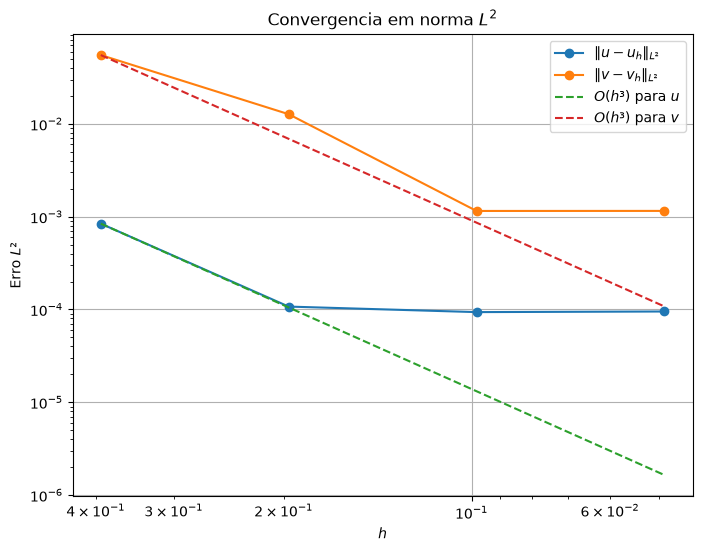

In [4]:
for n in ref:
    N = n
    mesh_ = RectangleMesh(N, N, np.pi, np.pi)

    V = FunctionSpace(mesh_, "CG", 2)
    W = MixedFunctionSpace([V, V, V]) #(u, v, w)

    d_const = Constant(1.0)
    rho0 = Constant(1.0)
    omega = 2.0 * sqrt(1.0)

    dt_val = 0.01
    dt = Constant(dt_val)
    T_final = 1.0
    n_steps = int(round(T_final/dt_val))

    up = Function(W)
    un = Function(W)

    u_np1, v_np1, w_np1 = split(up)
    u_n, v_n, w_n = split(un)

    phi, psi, chi = TestFunctions(W)

    u_bar = 0.5*(u_n + u_np1)
    v_bar = 0.5*(v_n + v_np1)
    w_bar = 0.5*(w_n + w_np1)

    f = Constant(0.0) #problema homohenio, 3b.4 roteiro. 

    F = (
        (u_np1 - u_n) / dt * phi * dx - v_bar * phi * dx
    + rho0 * (v_np1 - v_n) / dt * psi * dx + d_const * inner(grad(w_bar), grad(psi)) * dx
    - f * psi * dx
    + inner(grad(u_np1), grad(chi)) * dx - w_np1 * chi * dx
        )

    bc_u = DirichletBC(W.sub(0), 0.0, "on_boundary")
    bc_v = DirichletBC(W.sub(1), 0.0, "on_boundary")
    bc_w = DirichletBC(W.sub(2), 0.0, "on_boundary")

    x, y = SpatialCoordinate(mesh_)

    # Condições iniciais
    u0 = Function(V).interpolate(sin(x) * sin(y))          # u(0)
    un.sub(0).assign(u0)
    un.sub(1).assign(Constant(0.0))                        # v(0) = u_t(0) = 0

    # CORREÇÃO 2: w(0) discretamente consistente com u(0):
    # (w0, chi) = (grad u0, grad chi) para todo chi em V0, w0 = 0 no bordo
    w0 = Function(V)
    w_t, chi_t = TrialFunction(V), TestFunction(V)
    solve(w_t * chi_t * dx == inner(grad(u0), grad(chi_t)) * dx, w0,
    bcs=DirichletBC(V, 0.0, "on_boundary"),
    solver_parameters={"ksp_type": "preonly", "pc_type": "lu"})
    un.sub(2).assign(w0)

    problem = NonlinearVariationalProblem(F, up, bcs=[bc_u, bc_v, bc_w])

    # CORREÇÃO 3: problema linear -> um solve linear por passo, LU fatorada uma vez
    solver = NonlinearVariationalSolver(
    problem,
    solver_parameters={
    "snes_type": "ksponly",           # sem iterações de Newton
    "snes_lag_jacobian": -2,          # monta o Jacobiano uma vez e não remonta
    "snes_lag_preconditioner": -2,    # fatora a LU uma vez e reaproveita
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "superlu_dist",  # use "petsc" se não tiver MUMPS
            },
        )

    def energia(fun):
        _, v_h, w_h = split(fun)
        return (0.5 * float(rho0) * assemble(v_h * v_h * dx)
        + 0.5 * float(d_const) * assemble(w_h * w_h * dx))

    E0 = energia(un)
    drifts = [0.0]
    # CORREÇÃO 5: laço com contador inteiro (sem acúmulo de erro em t)
    for n in range(n_steps):
        solver.solve()
        un.assign(up)
        drifts.append((energia(un) - E0) / E0)
    
    print("Deriva máxima de energia |E_n - E_0|/E_0:", max(abs(d) for d in drifts))

    # CORREÇÃO 6: comparação com a solução exata (usa a expressão UFL diretamente)
    T = n_steps * dt_val
    u_ex = cos(omega * T) * sin(x) * sin(y)
    v_ex = -omega * sin(omega * T) * sin(x) * sin(y)
    u_h, v_h, w_h = un.subfunctions
    err_u = np.sqrt(assemble((u_h - u_ex) ** 2 * dx))
    err_v = np.sqrt(assemble((v_h - v_ex) ** 2 * dx))
    print(f"Erro L2 em T={T}: u = {err_u:.3e}, v = {err_v:.3e}")

    erros_u.append(err_u)
    erros_v.append(err_v)


print("="*20)
print("Erro de u")
for er_u in erros_u:
    print(f"Erro L2 de u:", er_u)
print("="*20)

print("="*20)
print("Erro de v")
for er_v in erros_v:
    print(f"Erro L2 de v:", er_v)
print("="*20)


h = np.array([np.pi/N for N in ref])

plt.figure(figsize=(8, 6))

#Erros
plt.loglog(h, erros_u, "o-", label= r"$\|u-u_h\|_{L²}$")
plt.loglog(h, erros_v, "o-", label= r"$\|v-v_h\|_{L²}$")

#Referencia O(h^3)
C_u = erros_u[0]/h[0]**3
C_v = erros_v[0]/h[0]**3

plt.loglog(
h,
C_u * h**3,
"--",
label=r"$O(h³)$ para $u$"
)

plt.loglog(
h,
C_v * h**3,
"--",
label=r"$O(h³)$ para $v$"
)

plt.gca().invert_xaxis()

plt.xlabel(r"$h$")
plt.ylabel(r"Erro $L²$")
plt.title(r"Convergencia em norma $L^2$")
plt.legend()
plt.grid()

plt.show()